# Phonon dispersion 

with Hydrogen

In [1]:
# prework

from vmatplot.phonon import plot_phonons
import matplotlib.pyplot as plt
from vmatplot.output_settings import figure_version, save_figure

figure_version("article")    # "thesis": thesis typography, figures saved as figures/<name>_thesis.pdf

y_range = [-10, 60]

'figures/phonon_2H-alpha-beryllene.pdf'

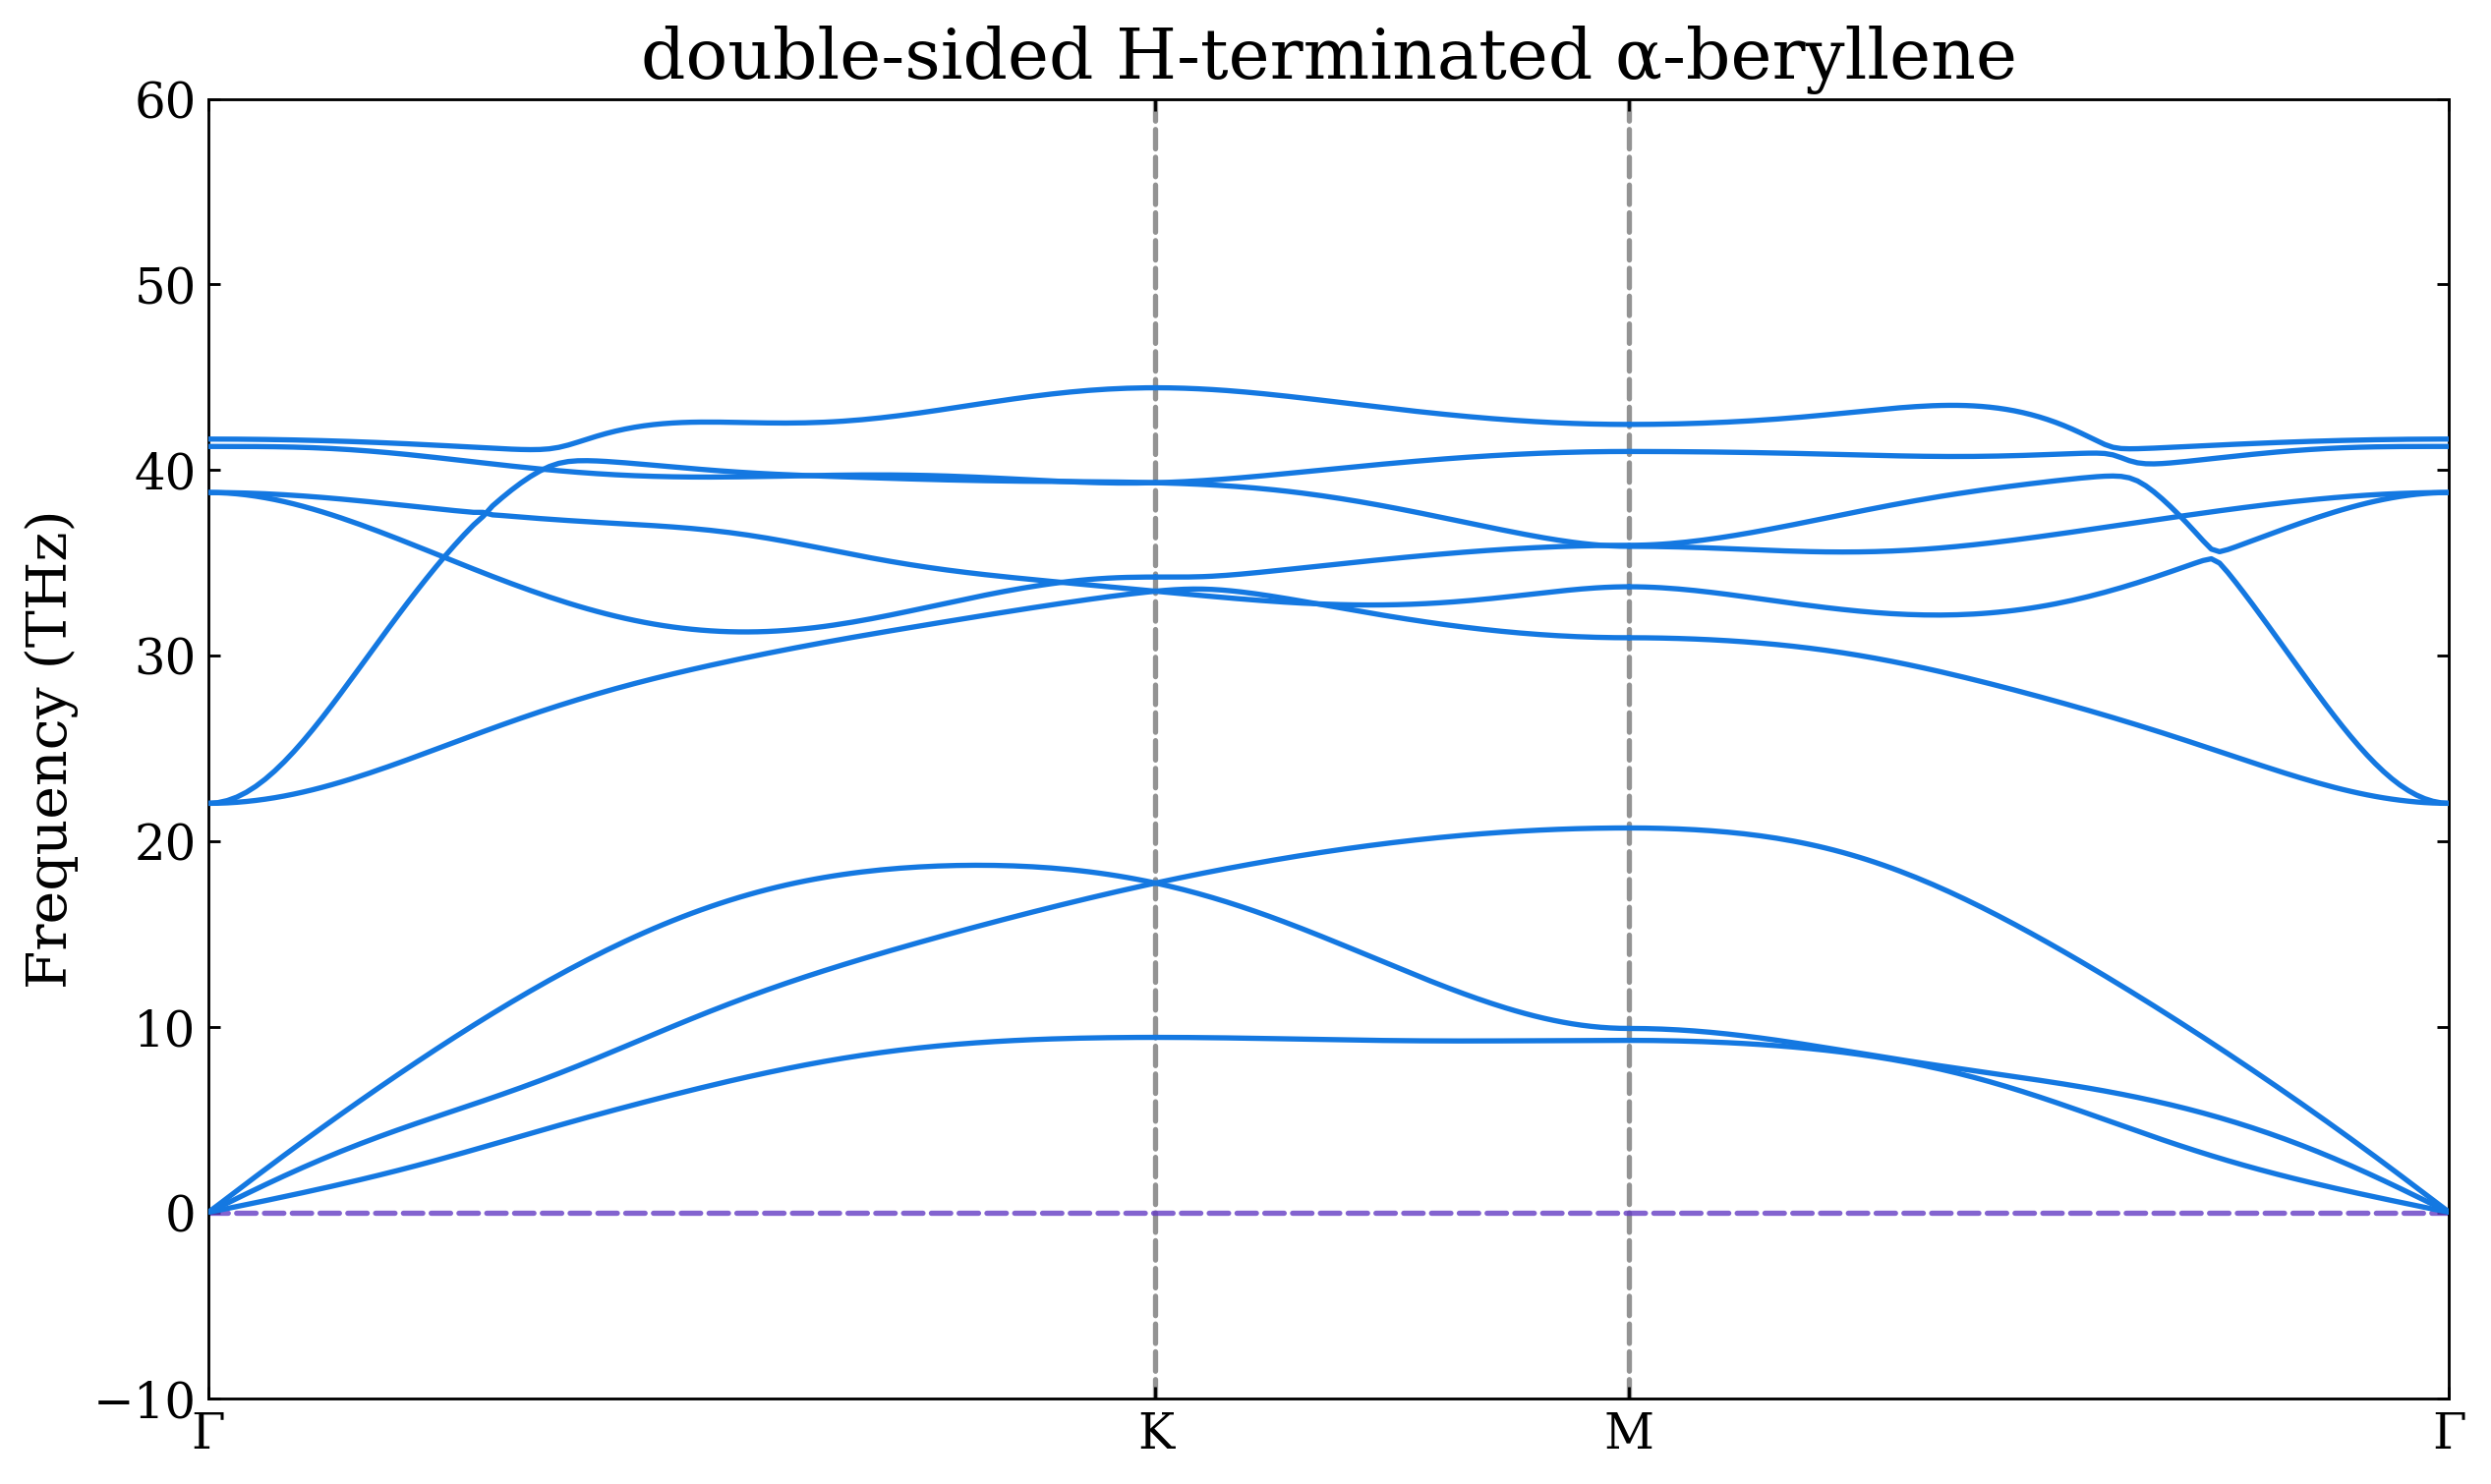

In [2]:
# α-beryllene with full freqence double side Hydrogen adhesion

# matters = [["α-beryllene", "3.1_phonon_dispersion_with_hydrogen_a/a-beryllene_hh2", "blue", "solid", 1.5, 1.0, 0]]
matters = [["α-beryllene", "3.7_phonon_dispersion_with_hydrogen_pbe/a-Beryllene_hh", "blue", "solid", 1.5, 1.0, 0]]

info = plot_phonons("double-sided H-terminated α-beryllene", matters, y_range, None)
save_figure("phonon_2H-alpha-beryllene")
# info
# fig = plt.gcf()
# fig.set_size_inches(8, 6)

'figures/phonon_1H-beta-beryllene.pdf'

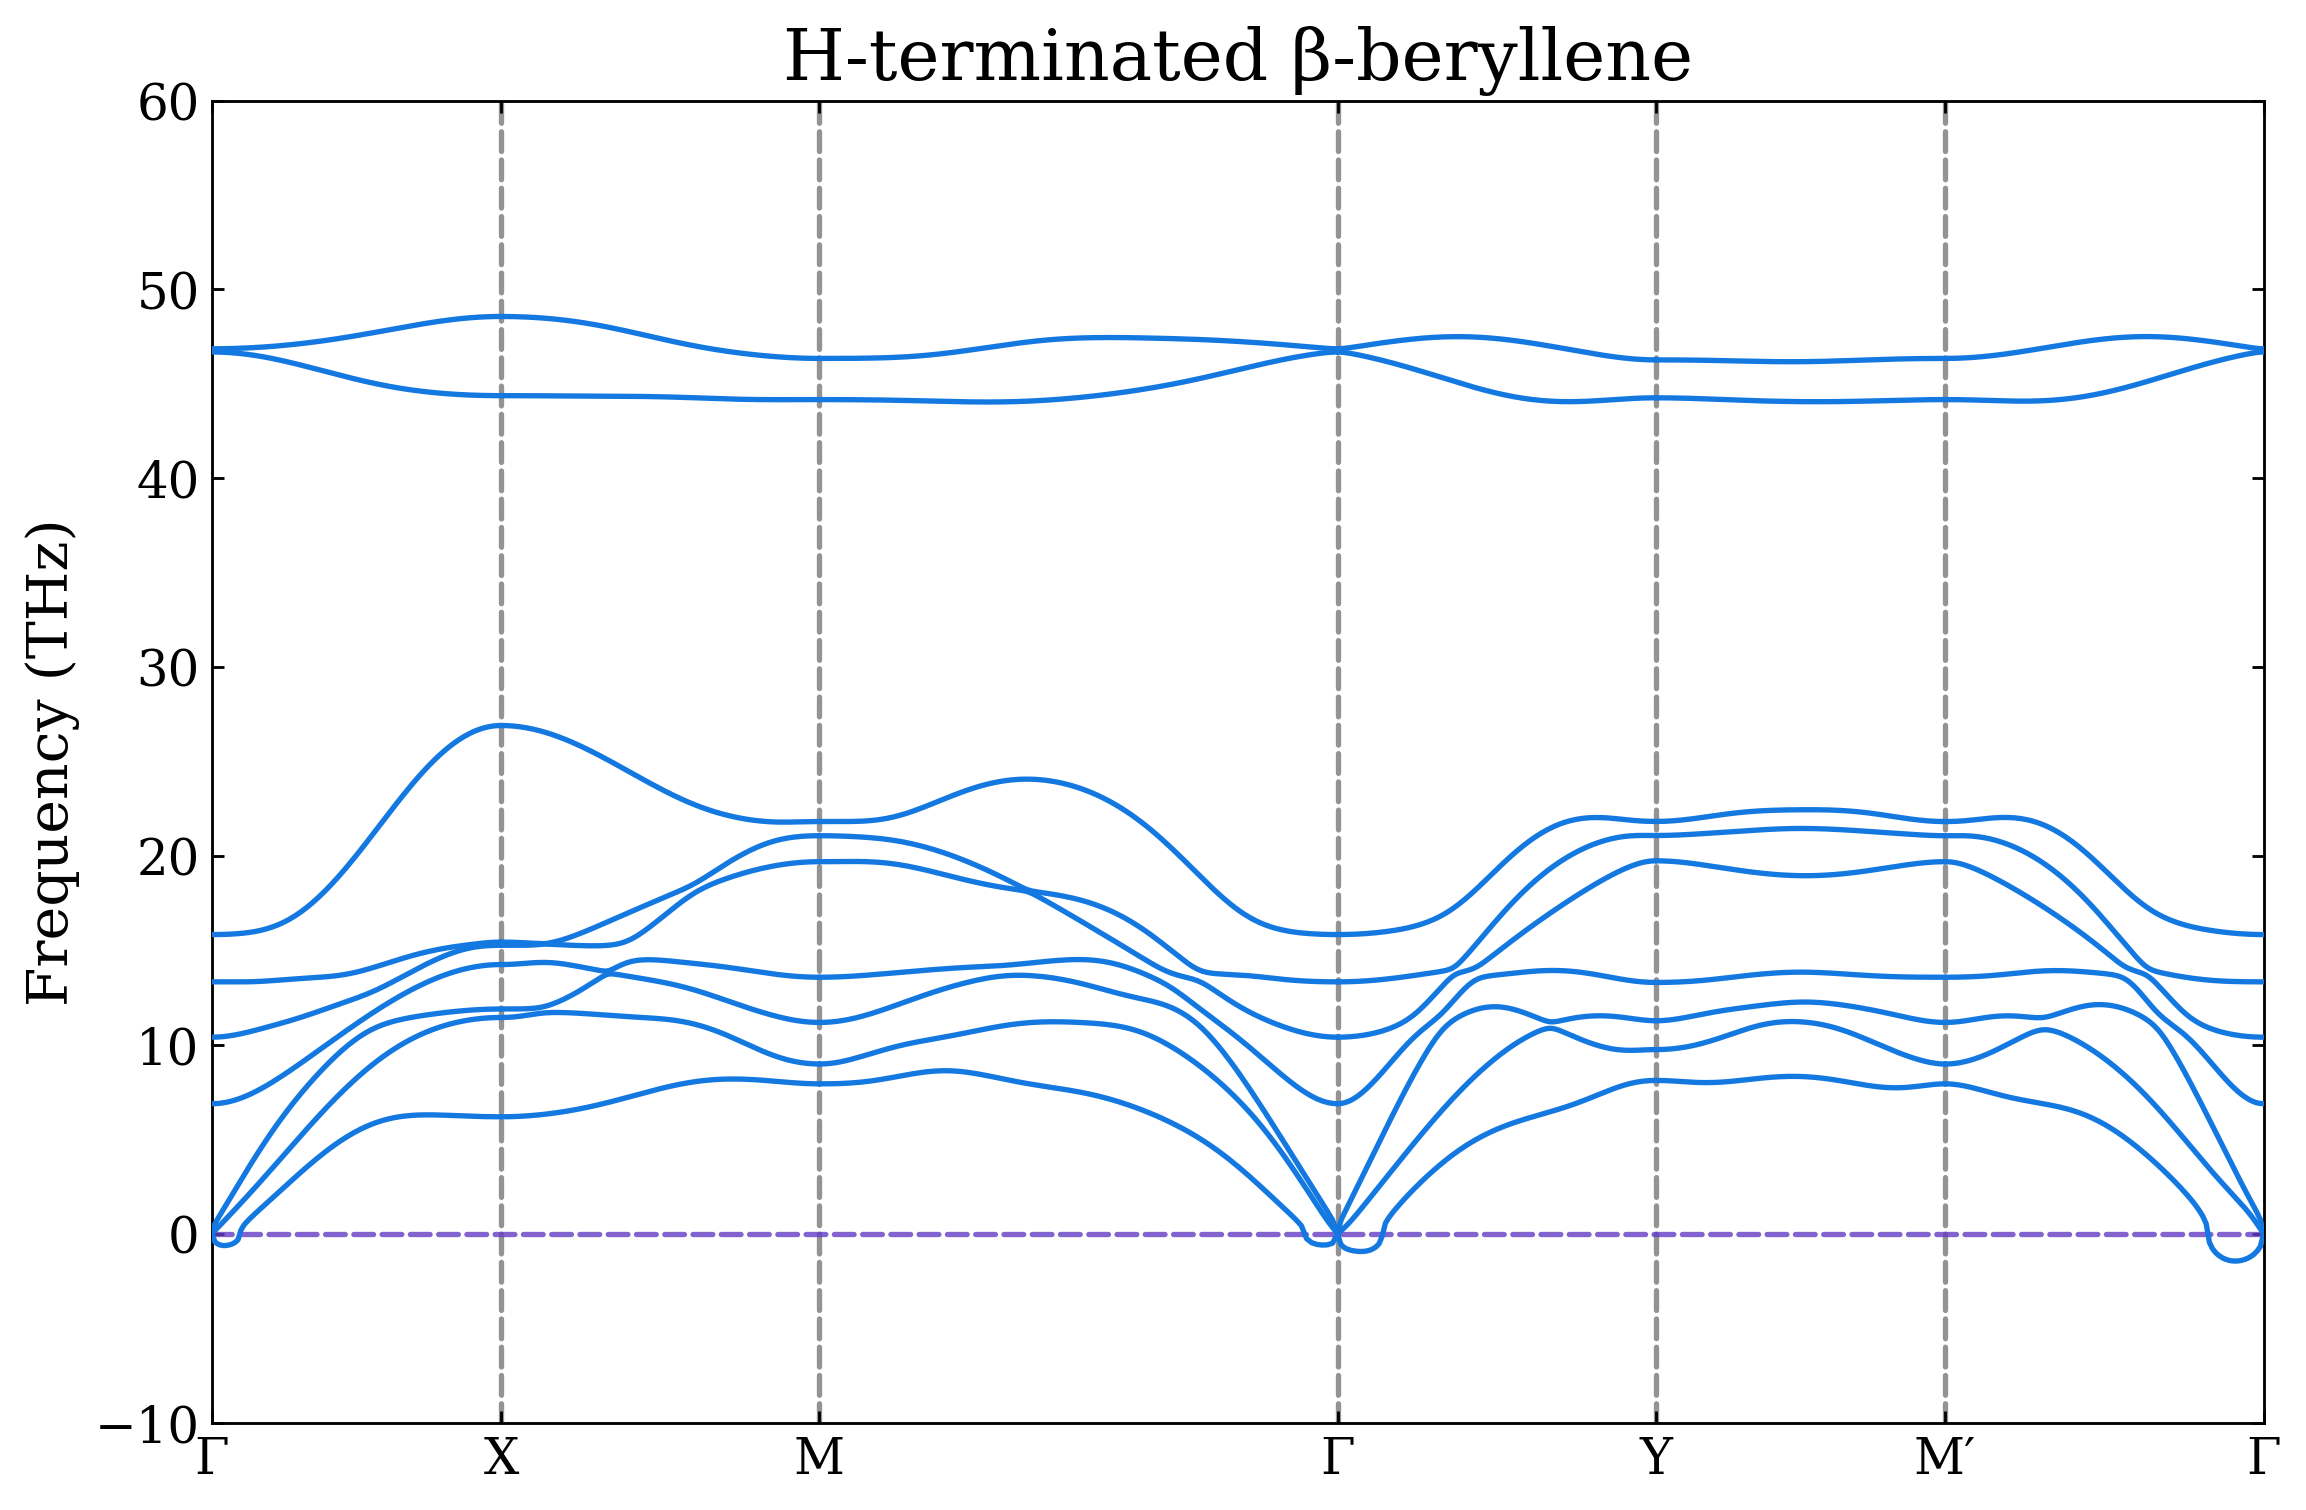

In [3]:
# β-beryllene with full freqence single side Hydrogen adhesion

matters = [["β-beryllene", "3.7_phonon_dispersion_with_hydrogen_pbe/b-Beryllene_b", "blue", "solid", 1.5, 1.0, 0]]
# matters = [["β-beryllene", "3.5_phonon_dispersion_with_hydrogen_selected/b-beryllene_b", "blue", "solid", 1.5, 1.0, 0]]

info = plot_phonons("H-terminated β-beryllene", matters, y_range, None)
info
fig = plt.gcf()
fig.set_size_inches(9, 6)
save_figure("phonon_1H-beta-beryllene")

'figures/phonon_2H-beta-beryllene.pdf'

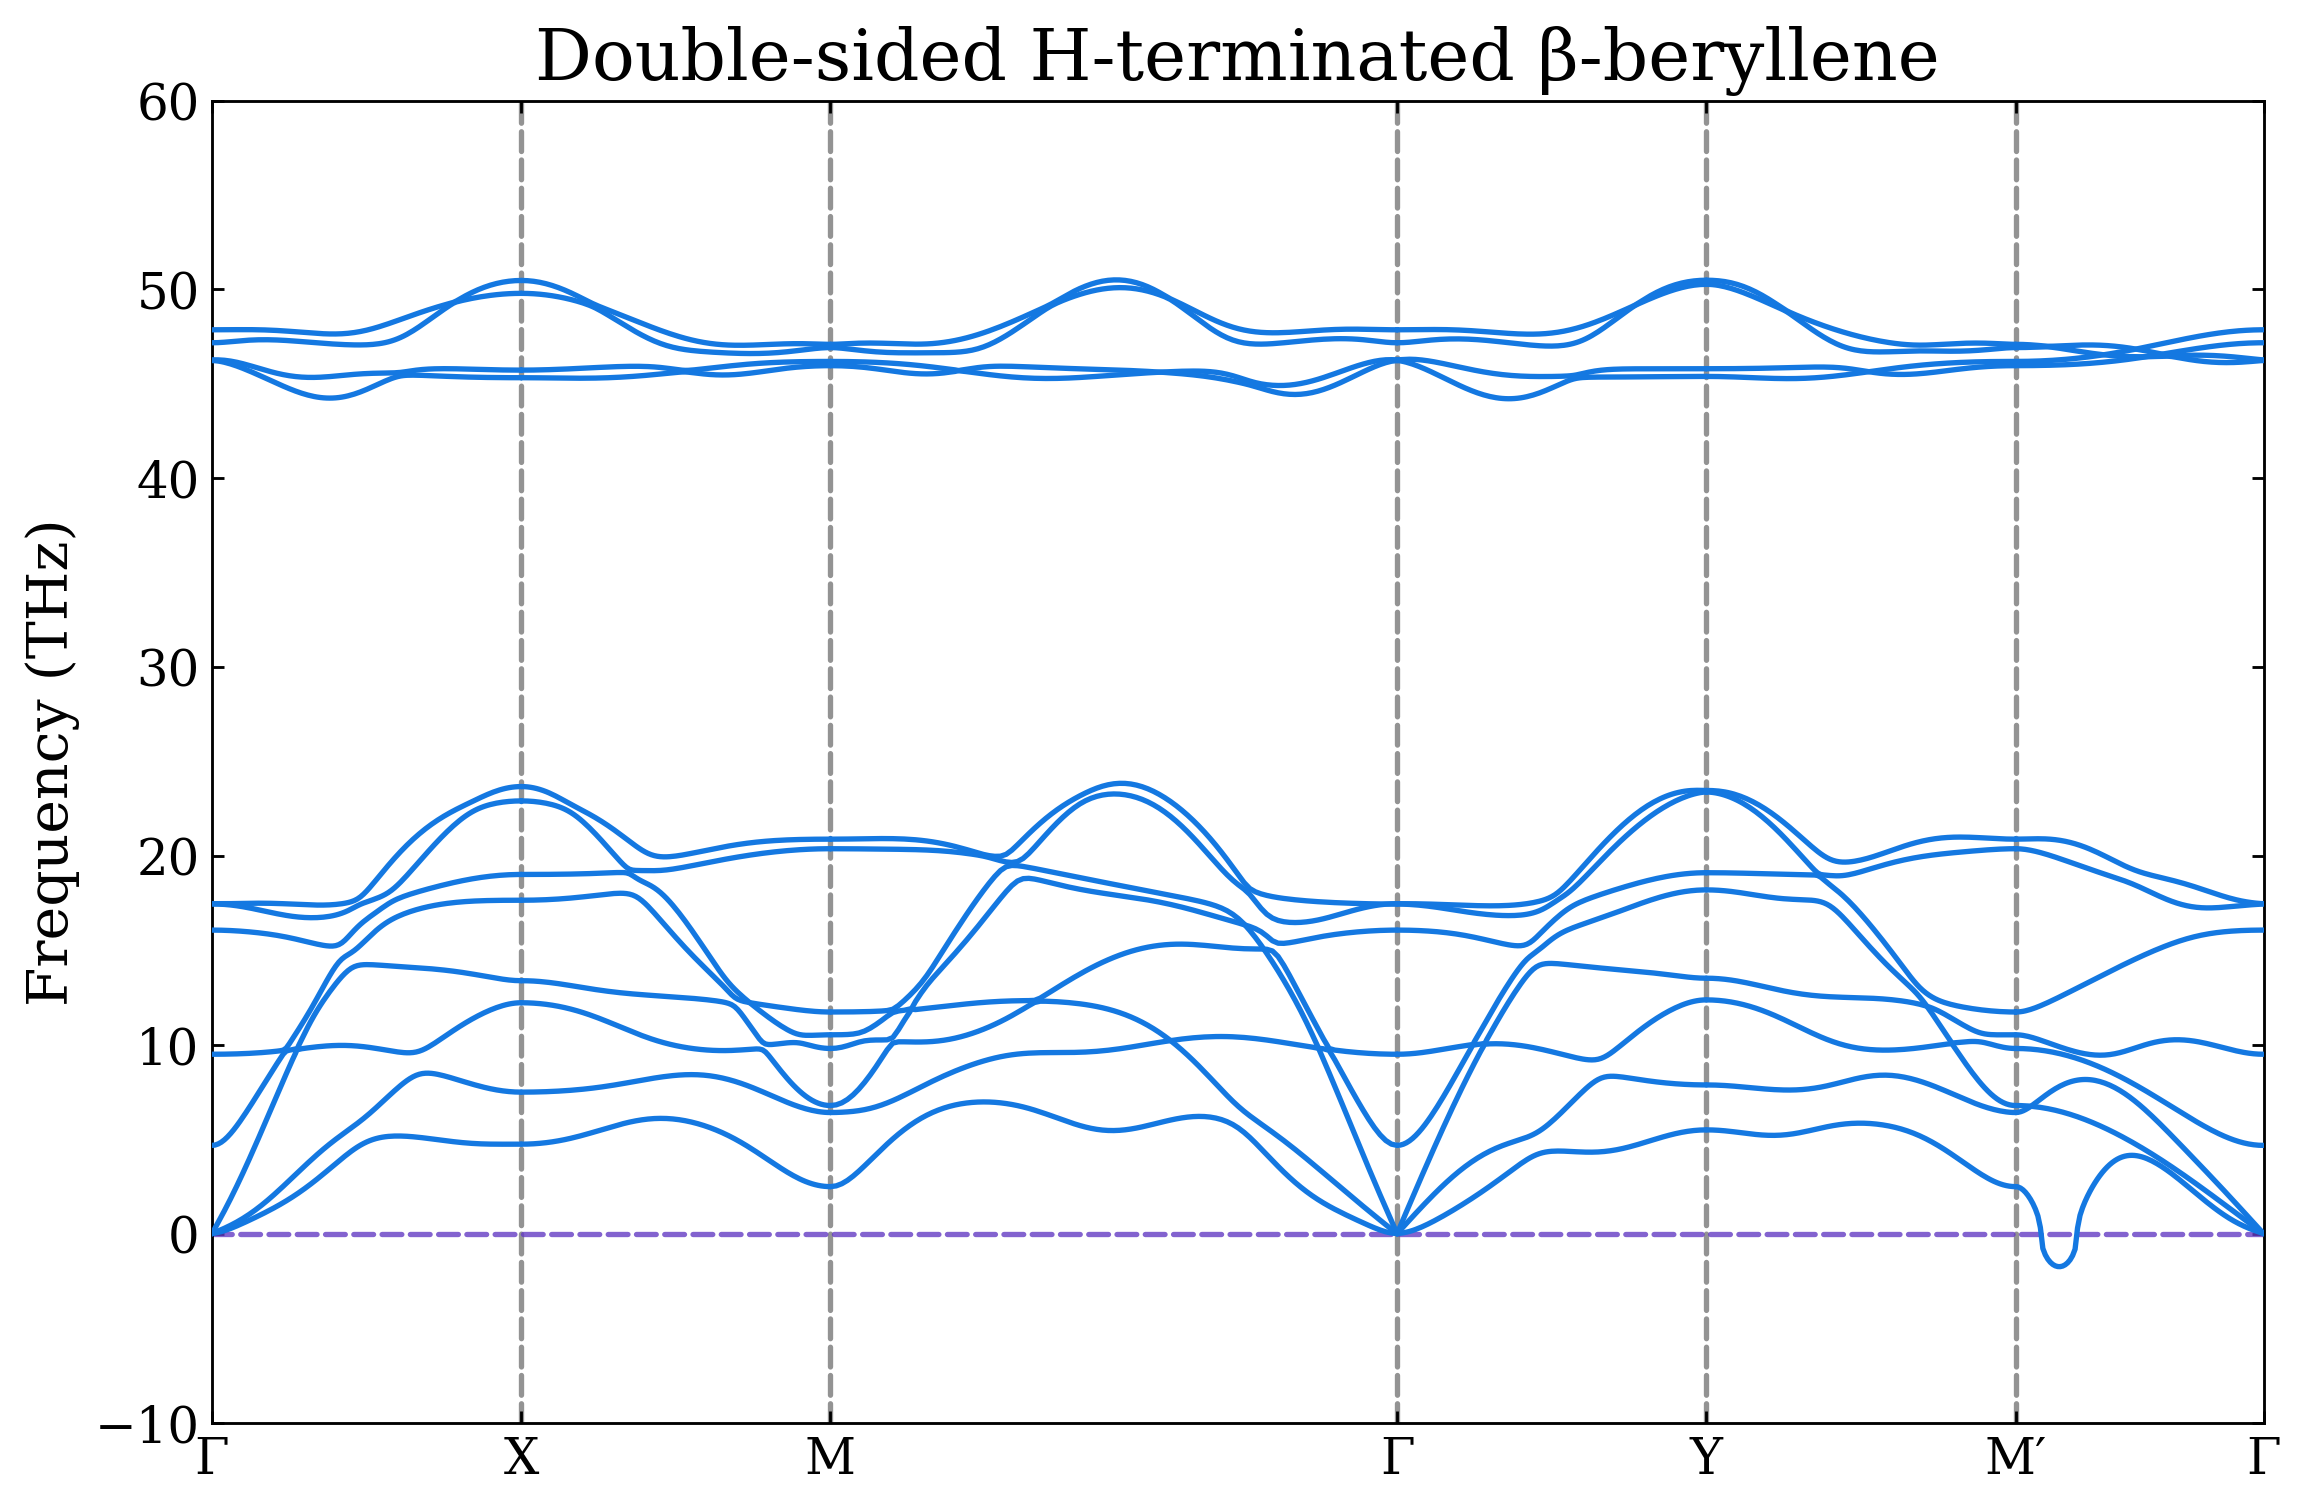

In [4]:
# β-beryllene with full freqence double side Hydrogen adhesion

# matters = [["β-beryllene", "3.2_phonon_dispersion_with_hydrogen_b/b-beryllene_tt", "blue", "solid", 1.5, 1.0, 0]]
matters = [["β-beryllene", "3.7_phonon_dispersion_with_hydrogen_pbe/b-Beryllene_bb", "blue", "solid", 1.5, 1.0, 0]]

info = plot_phonons("Double-sided H-terminated β-beryllene", matters, y_range, None)
info
fig = plt.gcf()
fig.set_size_inches(9, 6)
save_figure("phonon_2H-beta-beryllene")

## Dynamical stability (PBE, no D3)

`3.7_phonon_dispersion_with_hydrogen_pbe`: phonopy finite displacements (±0.01 Å, 5×5×1) with the relaxation settings (PBE without D3, SIGMA 0.05; 13×13 k for the metals, 7×7 for 2H-α). They replace the earlier runs, which used PBE+D3 and SIGMA 0.1 on the PBE geometries and a hexagonal Γ–K–M–Γ path that misses the inequivalent directions of the low-symmetry cells (audit: `3.5_phonon_dispersion_with_hydrogen_selected/audit_20260927.md`). 1H-β and 2H-β are plotted on Γ–X–M–Γ–Y–M′–Γ. Imaginary values that appear only on the interpolation grid near Γ belong to the flexural (ZA) branch: for 1H-β they lie at |q| ≤ 0.28 Å⁻¹, inside the nearest commensurate q of the 5×5 supercell (0.61 Å⁻¹), so the supercell does not resolve them. 2H-α is analysed with a symmetry tolerance of 1e-3 (P-3m1).

In [5]:
# Phonon stability of the hydrogenated beryllenes

from vmatplot.band_topology import summarize_phonon_stability, summarize_frozen_phonon, summarize_frozen_phonon_fit
from vmatplot.band_topology import summarize_lindhard, plot_lindhard_susceptibility

summarize_phonon_stability([["2H-α-beryllene", "3.7_phonon_dispersion_with_hydrogen_pbe/a-Beryllene_hh", 1e-3],
                            ["1H-β-beryllene", "3.7_phonon_dispersion_with_hydrogen_pbe/b-Beryllene_b"],
                            ["2H-β-beryllene", "3.7_phonon_dispersion_with_hydrogen_pbe/b-Beryllene_bb"]]);

| Structure | Directory | Forces | Space group | Residual force (eV/Å) | Min. ν, commensurate q (THz) | Min. ν, 60×60 grid (THz) | Max. ν (THz) |
|---|---|---|---|---|---|---|---|
| 2H-α-beryllene | 3.7_phonon_dispersion_with_hydrogen_pbe/a-Beryllene_hh | PBE, SIGMA 0.05, k 7×7 | P-3m1 (164) | 4.6e-04 | -0.000 | -0.000 at q = (0, 0) | 44.4 |
| 1H-β-beryllene | 3.7_phonon_dispersion_with_hydrogen_pbe/b-Beryllene_b | PBE, SIGMA 0.05, k 13×13 | P1 (1) | 9.9e-03 | -0.000 | -1.446 at q = (0.033, -0.05) | 48.6 |
| 2H-β-beryllene | 3.7_phonon_dispersion_with_hydrogen_pbe/b-Beryllene_bb | PBE, SIGMA 0.05, k 13×13 | P-1 (2) | 6.9e-03 | -1.649 | -1.764 at q = (-0.417, 0.4) | 50.5 |

### The 2H-β soft mode, q = (0.4, 0.6)

The PBE run gives −1.649 THz at the commensurate q = (0.4, 0.6) (POSCAR reciprocal basis; ≡ −(−0.4, 0.4), on the Γ–M′ segment of the dispersion), with the same eigenvector as the earlier PBE+D3 run (overlap 1.000, −0.646 THz there); the imaginary pocket covers 1.1% of the BZ. Frozen phonon (`3.6_phonon_soft_mode_check/b-Beryllene_bb`): 20-atom supercell A1 = 5a1, A2 = a1 + a2, modulated along this eigenvector with maximum displacement 0 / 0.025 / 0.049 / 0.098 Å (A0 / A05 / A1 / A2); PBE, no D3, SIGMA 0.05, unit-cell-equivalent 65×65 k.

In [6]:
# Frozen phonon, SIGMA 0.05 eV

summarize_frozen_phonon("3.6_phonon_soft_mode_check/b-Beryllene_bb");

| Amplitude | E0 (eV) | E0 − E0(A0) (meV) |
|---|---|---|
| A0 | -68.907118 | +0.00 |
| A05 | -68.907131 | -0.01 |
| A1 | -68.906540 | +0.58 |
| A2 | -68.894668 | +12.45 |

Electronic-temperature dependence (SIGMA = 0.02 eV with a 97×97-equivalent k mesh, 0.10 eV with 65×65) and a fit E = αQ² + βQ⁴ in the mass-weighted amplitude Q. The harmonic term is negative (about 1.0i–1.1i THz at SIGMA 0.05–0.10 eV; the finite-displacement value at ±0.01 Å is 1.65i THz), but the double well is only 0.02–0.03 meV per 20-atom cell, far below the zero-point energy of the mode (ħω/2 ≈ 2 meV for ω/2π ≈ 1 THz): no static distortion is expected, and the mode is strongly anharmonic. The SIGMA = 0.02 eV series is not converged in k (fit residual 0.16 meV) and does not resolve the harmonic term.

In [7]:
# Frozen phonon, SIGMA 0.02 and 0.10 eV, and the quartic fit

summarize_frozen_phonon("3.6_phonon_soft_mode_check/b-Beryllene_bb/sigma_0.02");
summarize_frozen_phonon("3.6_phonon_soft_mode_check/b-Beryllene_bb/sigma_0.10");
summarize_frozen_phonon_fit([["SIGMA 0.02", "3.6_phonon_soft_mode_check/b-Beryllene_bb/sigma_0.02"],
                             ["SIGMA 0.05", "3.6_phonon_soft_mode_check/b-Beryllene_bb"],
                             ["SIGMA 0.10", "3.6_phonon_soft_mode_check/b-Beryllene_bb/sigma_0.10"]]);

| Amplitude | E0 (eV) | E0 − E0(A0) (meV) |
|---|---|---|
| A0 | -68.904748 | +0.00 |
| A05 | -68.904733 | +0.02 |
| A1 | -68.904755 | -0.01 |
| A2 | -68.894719 | +10.03 |

| Amplitude | E0 (eV) | E0 − E0(A0) (meV) |
|---|---|---|
| A0 | -68.906802 | +0.00 |
| A05 | -68.906814 | -0.01 |
| A1 | -68.906307 | +0.50 |
| A2 | -68.894870 | +11.93 |

| Series | SIGMA (eV) | Supercell k | E − E(A0) in meV (max \|u\|) | Harmonic ν (THz, − = imaginary) | Double-well depth (meV / cell) | Max. fit residual (meV) |
|---|---|---|---|---|---|---|
| SIGMA 0.02 | 0.02 | 16×97 | +0.015 (0.025 Å), -0.007 (0.049 Å), +10.029 (0.098 Å) | -1.75 | 0.185 at max \|u\| = 0.034 Å | 0.158 |
| SIGMA 0.05 | 0.05 | 11×65 | -0.013 (0.025 Å), +0.578 (0.049 Å), +12.450 (0.098 Å) | -1.02 | 0.021 at max \|u\| = 0.019 Å | 0.001 |
| SIGMA 0.10 | 0.10 | 11×65 | -0.012 (0.025 Å), +0.495 (0.049 Å), +11.932 (0.098 Å) | -1.13 | 0.032 at max \|u\| = 0.022 Å | 0.018 |

One-mode quantum estimate. Treating Q as one mode of the 20-atom supercell (kinetic energy Q̇²/2), the exact eigenstates of the fitted potential and the self-consistent harmonic frequency of that mode give a real frequency of about 4 THz at 0 K for all three SIGMA (5.5–5.7 THz at 300 K). The zero-point energy, about 6 meV above the well bottom, exceeds the double well 30–300 times, and the ground state stays centred at Q = 0. A static distortion would need α ≈ −45 to −50 meV amu⁻¹ Å⁻² (a harmonic frequency near 5i THz), against −2.1 to −6.2 meV amu⁻¹ Å⁻² from the fits. The soft mode is a longitudinal in-plane Be mode along a1 − a2: the shortest equivalent wave vector (0.4, −0.4) is |q| = 1.06 Å⁻¹ along x, the Be atoms move along ±x (99% of the mass-weighted amplitude on Be, 84% in-plane), Be–Be bonds change by up to ±0.04 Å at A2 and the Be–H bonds stay within 0.006 Å; the A2 displacement overlaps the PBE eigenvector at 0.9999. The frequency does not depend on the form of the fit (3.99–4.00 THz for SIGMA 0.05 with a sextic term or with two-point fits) or on using the finite-displacement value of α (3.85 THz for 1.65i THz). Coupling to the other modes is left out, so this sizes the quantum fluctuations but does not replace a full SSCHA; the 300 K values extrapolate beyond the sampled amplitudes (Q ≤ 0.71 amu^½ Å).

In [8]:
# One-mode quantum estimate of the soft mode

from vmatplot.band_topology import summarize_frozen_phonon_quantum

summarize_frozen_phonon_quantum([["SIGMA 0.02", "3.6_phonon_soft_mode_check/b-Beryllene_bb/sigma_0.02"],
                                 ["SIGMA 0.05", "3.6_phonon_soft_mode_check/b-Beryllene_bb"],
                                 ["SIGMA 0.10", "3.6_phonon_soft_mode_check/b-Beryllene_bb/sigma_0.10"]], temperatures=(0, 300));

| Series | Harmonic ν (THz) | Well depth (meV) | E₀ above the well bottom (meV) | Exact E₁ − E₀ (THz) | One-mode SCHA ν at 0 K (THz) | One-mode SCHA ν at 300 K (THz) | √⟨Q²⟩₀ / Q at the minimum (amu^½ Å) |
|---|---|---|---|---|---|---|---|
| SIGMA 0.02 | -1.75 | 0.185 | 5.88 | 3.77 | 4.03 | 5.54 | 0.364 / 0.243 |
| SIGMA 0.05 | -1.02 | 0.021 | 6.31 | 4.00 | 4.23 | 5.67 | 0.354 / 0.140 |
| SIGMA 0.10 | -1.13 | 0.032 | 6.21 | 3.95 | 4.18 | 5.63 | 0.356 / 0.157 |

### Fermi-surface nesting at the soft-mode wave vector

Constant-matrix-element static susceptibility χ₀(q) and nesting function ξ(q) from the unfolded 105×105 SOC SCF eigenvalues of 2H-β (`9.0_topology/b-Beryllene_bb`, bands with states within ±1 eV of E_F; windows of ±0.5 and ±2 eV select the same spinor bands 5–8). A nesting-driven soft mode would sit at a peak of χ₀ or ξ; the crosses mark q = (0.4, 0.6) and its symmetry images. Neither function peaks there, so the softening is not nesting-driven.

| Structure | q | σ (eV) | χ₀(q) | χ₀ rank | χ₀ max (q ≠ 0) | ξ(q) | ξ rank | ξ max (q ≠ 0) |
|---|---|---|---|---|---|---|---|---|
| 2H-β | (0.4, 0.6) | 0.02 | 1.714 | 8935/11024 | 2.546 at (0.105, 0.114) | 0.004 | 8405/11024 | 1.562 at (-0.010, 0.010) |
| 2H-β | (0.4, 0.6) | 0.05 | 1.724 | 8813/11024 | 2.499 at (0.114, 0.105) | 0.079 | 7413/11024 | 2.641 at (0.010, -0.010) |
| 2H-β | (0.4, 0.6) | 0.10 | 1.730 | 8723/11024 | 2.428 at (-0.114, -0.105) | 0.096 | 3806/11024 | 1.663 at (0.010, -0.010) |

'figures/nesting_2H-beta-beryllene.pdf'

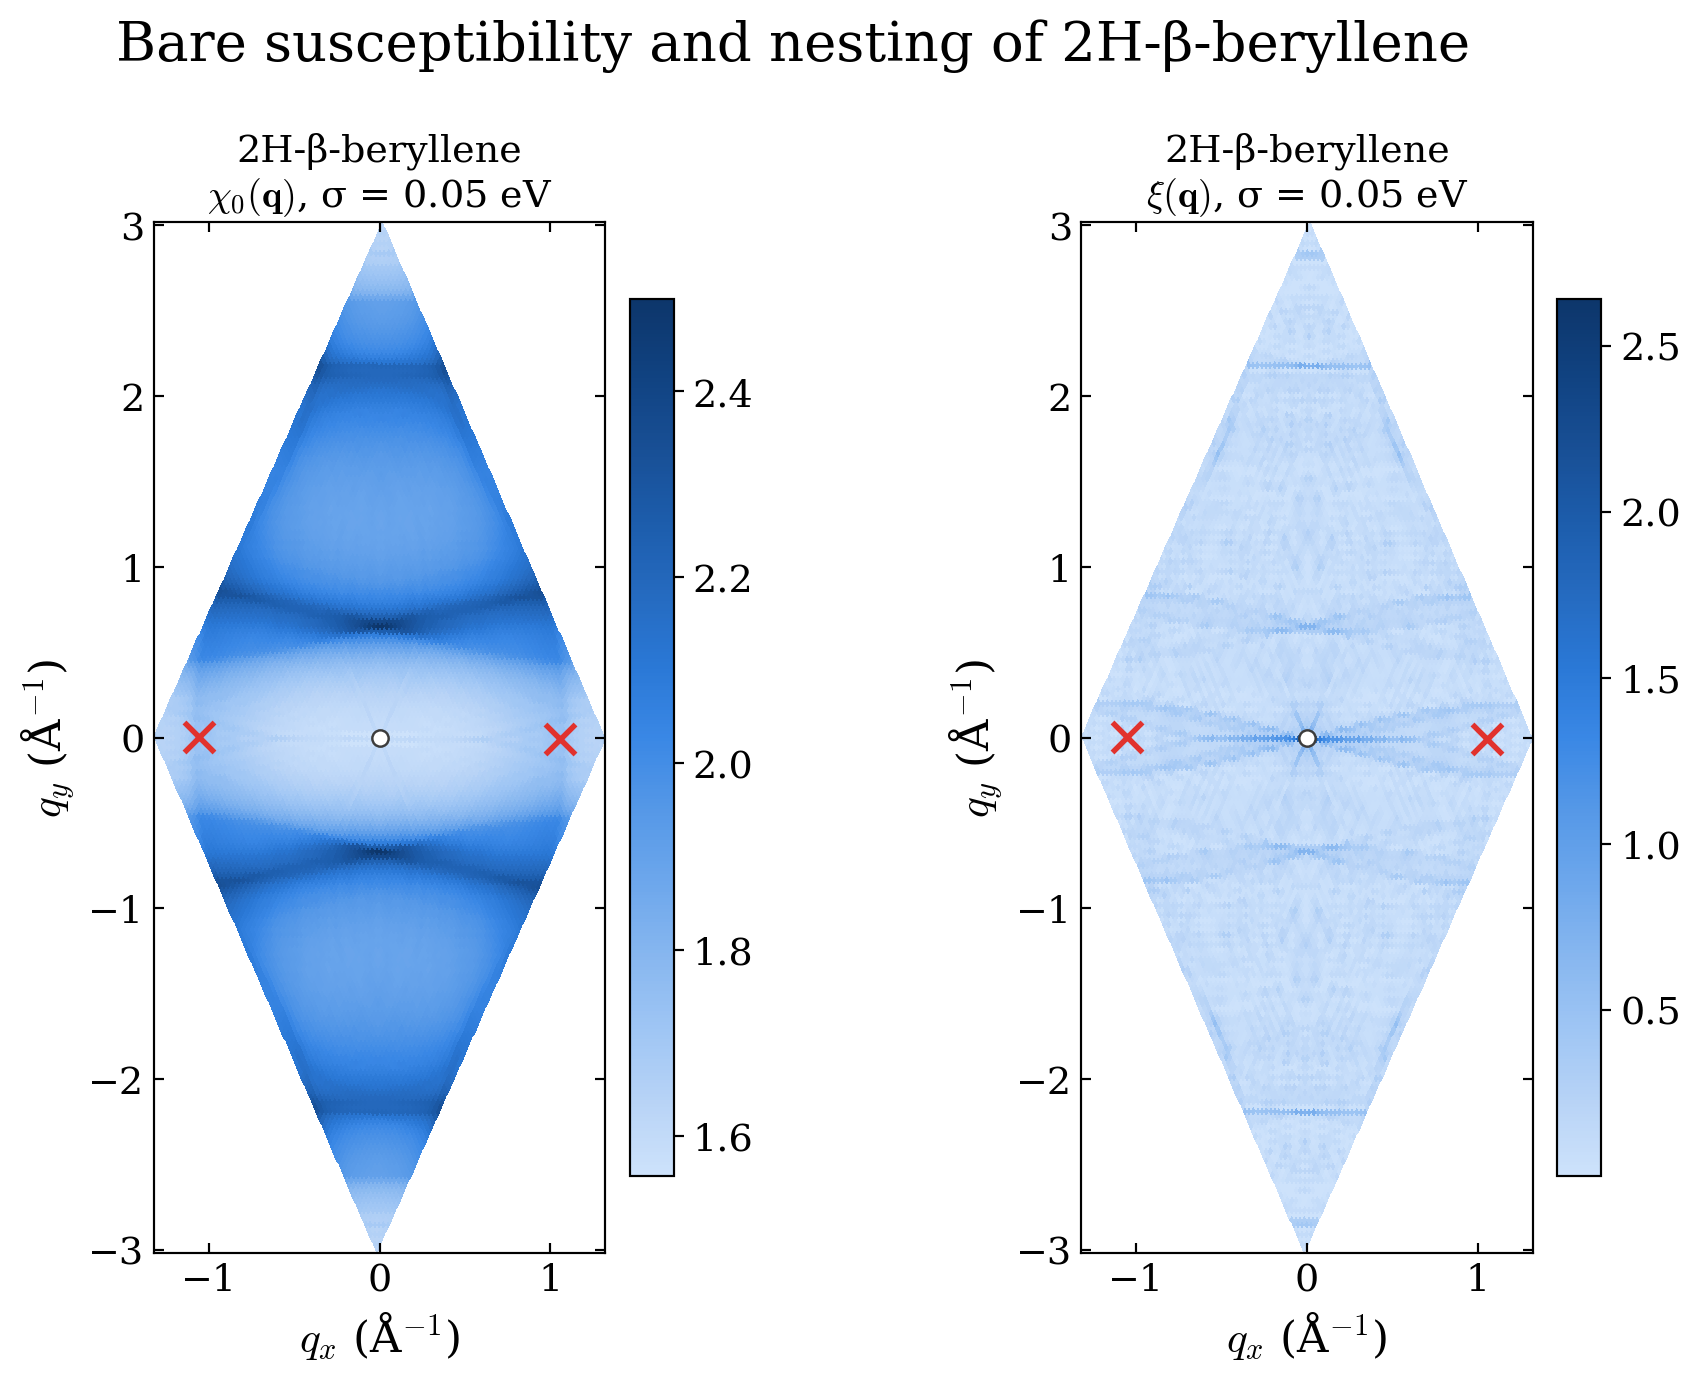

In [9]:
# Bare susceptibility and nesting of 2H-β

summarize_lindhard([["2H-β", "9.0_topology/b-Beryllene_bb", (0.4, 0.6)]]);
plot_lindhard_susceptibility("Bare susceptibility and nesting of 2H-β-beryllene", [["2H-β-beryllene", "9.0_topology/b-Beryllene_bb", (0.4, 0.6)]])
save_figure("nesting_2H-beta-beryllene", bbox_inches="tight")